<a href="https://colab.research.google.com/github/its-asif/ML-testing/blob/main/salary_data_eda/salary_data_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv
from scipy.stats import chi2

# Important Function

In [10]:
def plot_histogram(data, column, bins=50, figsize=(10, 6), kde=True, color='skyblue', edgecolor='black',
                           title='Histogram', xlabel='X-axis', ylabel='Frequency'):
    """
    Plots a histogram using Seaborn's histplot for detailed visualization.

    Parameters:
    - data: DataFrame containing the data.
    - column: Column name for which to plot the histogram.
    - bins: Number of bins for the histogram (default is 50).
    - figsize: Size of the figure (default is (10, 6)).
    - kde: Boolean to include a KDE curve (default is True).
    - color: Color of the histogram bars (default is 'skyblue').
    - edgecolor: Color of the edges of the bars (default is 'black').
    - title: Title of the histogram (default is 'Histogram').
    - xlabel: Label for the x-axis (default is 'X-axis').
    - ylabel: Label for the y-axis (default is 'Frequency').

    Returns:
    - None
    """
    plt.figure(figsize=figsize)
    sns.histplot(data=data, x=column, bins=bins, kde=kde, color=color, edgecolor=edgecolor)

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.show()


In [11]:
def plot_boxplot(data, column, figsize=(10, 6), color='lightblue', median_line_color='red', title='Box Plot',
                 xlabel='X-axis', ylabel='Y-axis', log_transform=False, categorical_col=None):
    """
    Plots a customized box plot. Can plot both a simple box plot and a bivariate box plot grouped by a categorical variable.

    Parameters:
    - data (DataFrame): DataFrame containing the data.
    - column (str): Column name for which to plot the box plot.
    - figsize (tuple): Size of the figure (default is (10, 6)).
    - color (str): Color of the box plot (default is 'lightblue').
    - median_line_color (str): Color of the median line (default is 'red').
    - title (str): Title of the box plot (default is 'Box Plot').
    - xlabel (str): Label for the x-axis (default is 'X-axis').
    - ylabel (str): Label for the y-axis (default is 'Y-axis').
    - log_transform (bool): Boolean to apply log transformation to the column values (default is False).
    - categorical_col (str, optional): Name of the categorical column to group by for a bivariate plot.

    Returns:
    - None
    """
    plt.figure(figsize=figsize)

    # Apply log transformation if specified
    if log_transform:
        data = data.copy()
        data[column] = np.log1p(data[column])  # Using log1p to handle zero values and avoid negative results

    # Determine if this is a single or bivariate plot
    if categorical_col:
        sns.boxplot(x=categorical_col, y=column, data=data)
        xlabel = categorical_col  # Adjusting the x-label to reflect the categorical column
        ylabel = column
    else:
        sns.boxplot(data=data, x=column, color=color, medianprops=dict(color=median_line_color))

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


In [12]:
def plot_bar_chart(data, x_column, title, xlabel, ylabel, figsize=(6, 4), palette="pastel",
                   log_scale=False, bar_width=0.8, hue_column=None, y_column=None, x_label_rotation=0, y_range=None):
    """
    Plots various types of distributions for categorical or numerical data.

    Parameters:
    - data (DataFrame): The DataFrame containing the data.
    - x_column (str): The name of the primary column to plot on the x-axis.
    - title (str): The title of the plot.
    - xlabel (str): The label for the x-axis.
    - ylabel (str): The label for the y-axis.
    - figsize (tuple): The size of the figure (default is (6, 4)).
    - palette (str): The color palette for the plot (default is "pastel").
    - log_scale (bool): Whether to use a logarithmic scale for the y-axis (default is False).
    - bar_width (float): The width of the bars in the histogram (default is 0.8).
    - hue_column (str, optional): The name of the categorical column to group by for side-by-side bars.
    - y_column (str, optional): The name of the numerical column for y-values; defaults to count if None.
    - x_label_rotation (int, optional): The rotation angle for the x-axis labels (default is 0).
    - y_range (tuple, optional): The range (min, max) for the y-axis.

    Returns:
    None: Displays the plot.
    """
    sns.set(style="whitegrid")
    plt.figure(figsize=figsize)

    if y_column:
        # Use a numerical column for y-values, requires aggregation
        if hue_column:
            # Grouped numerical plot
            sns.barplot(x=x_column, y=y_column, hue=hue_column, data=data, palette=palette, errorbar=None)
        else:
            # Simple numerical plot
            sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)
    else:
        # Default to counting occurrences
        if hue_column:
            # Grouped count plot
            sns.countplot(x=x_column, hue=hue_column, data=data, palette=palette)
        else:
            # Simple count plot
            sns.countplot(x=x_column, data=data, palette=palette)

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    if y_range:
        plt.ylim(y_range)

    if log_scale:
        plt.yscale('log')

    # Rotate x-axis labels if specified
    plt.xticks(rotation=x_label_rotation)

    plt.show()


In [13]:
def mahalanobis_distances(df):
    """
    Calculate Mahalanobis distances for each row in the dataframe `df`.

    Parameters:
    df (pd.DataFrame): DataFrame containing numerical data.

    Returns:
    pd.Series: Series containing Mahalanobis distances for each row.
    """
    # Ensure the dataframe only contains numerical data
    df = df.select_dtypes(include=[np.number])

    # Calculate the mean vector
    mean_vector = df.mean().values

    # Calculate the covariance matrix and its inverse
    covariance_matrix = np.cov(df, rowvar=False)
    inv_cov_matrix = inv(covariance_matrix)

    # Function to compute the Mahalanobis distance for a single row
    def mahalanobis_distance(row):
        delta = row - mean_vector
        return mahalanobis(delta, np.zeros_like(mean_vector), inv_cov_matrix)

    # Compute distances for each row
    distances = df.apply(mahalanobis_distance, axis=1)

    return distances

In [14]:
def calculate_threshold(df, alpha=0.05):
    """
    Calculate the threshold for Mahalanobis distance based on the chi-square distribution.

    Parameters:
    df (pd.DataFrame): DataFrame containing numerical data.
    alpha (float): Significance level for outlier detection (default 0.05).

    Returns:
    float: Threshold for Mahalanobis distance.
    """
    # Number of features (dimensions)
    p = df.shape[1]

    # Chi-square critical value
    threshold = chi2.ppf(1 - alpha, df=p)

    return threshold

# Data collection and Exploration

In [15]:
# Read the CSV file with the correct delimiter
jobs = pd.read_csv('/content/glassdoor_jobs.csv', delimiter=',')
jobs.drop(['Unnamed: 0'], axis=1, inplace = True)

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
jobs.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [18]:
print("Total enteries : ",jobs.shape[0])
print("Total attributes : ",jobs.shape[1])

Total enteries :  956
Total attributes :  14


In [19]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          956 non-null    object 
 1   Salary Estimate    956 non-null    object 
 2   Job Description    956 non-null    object 
 3   Rating             956 non-null    float64
 4   Company Name       956 non-null    object 
 5   Location           956 non-null    object 
 6   Headquarters       956 non-null    object 
 7   Size               956 non-null    object 
 8   Founded            956 non-null    int64  
 9   Type of ownership  956 non-null    object 
 10  Industry           956 non-null    object 
 11  Sector             956 non-null    object 
 12  Revenue            956 non-null    object 
 13  Competitors        956 non-null    object 
dtypes: float64(1), int64(1), object(12)
memory usage: 104.7+ KB


In [20]:
jobs.describe()

,Rating,Founded
count,956.000000,956.000000
mean,3.601255,1774.605649
std,1.067619,598.942517
min,-1.000000,-1.000000
25%,3.300000,1937.000000
50%,3.800000,1992.000000
75%,4.200000,2008.000000
max,5.000000,2019.000000


In [21]:
jobs.describe(include = ['object', 'category'])

,Job Title,Salary Estimate,Job Description,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,Competitors
count,956,956,956,956,956,956,956,956,956,956,956,956
unique,328,417,596,448,237,235,9,13,63,25,14,149
top,Data Scientist,-1,Data Engineer with R\n\n-Contract Role in Atla...,Takeda Pharmaceuticals\n3.7,"New York, NY","New York, NY",1001 to 5000 employees,Company - Private,Biotech & Pharmaceuticals,Information Technology,Unknown / Non-Applicable,-1
freq,178,214,4,14,78,75,177,532,148,239,299,634


In [22]:
jobs.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

# Data Cleaning

## Dropping Irrelevant Columns

In [23]:
jobs.drop(columns = ['Headquarters', 'Founded', 'Competitors', 'Job Description', 'Industry'], axis = 1, inplace = True)

In [24]:
jobs.head(3)

,Job Title,Salary Estimate,Rating,Company Name,Location,Size,Type of ownership,Sector,Revenue
0,Data Scientist,$53K-$91K (Glassdoor est.),3.8,Tecolote Research\n3.8,"Albuquerque, NM",501 to 1000 employees,Company - Private,Aerospace & Defense,$50 to $100 million (USD)
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),3.4,University of Maryland Medical System\n3.4,"Linthicum, MD",10000+ employees,Other Organization,Health Care,$2 to $5 billion (USD)
2,Data Scientist,$80K-$90K (Glassdoor est.),4.8,KnowBe4\n4.8,"Clearwater, FL",501 to 1000 employees,Company - Private,Business Services,$100 to $500 million (USD)


## Removing Duplicates

In [25]:
len(jobs[jobs.duplicated()])

356

In [26]:
jobs.drop_duplicates(inplace = True)

## Null Values

In [27]:
jobs.isna().sum()

,0
Job Title,0
Salary Estimate,0
Rating,0
Company Name,0
Location,0
Size,0
Type of ownership,0
Sector,0
Revenue,0


## Membership constraints

In [28]:
for col in jobs.columns:
    if jobs[col].dtype == "category":
        print(f"Unique values in \"{col}\" column are \n:{jobs[col].unique().to_list()}\n\n")

- As we can see there is an inappropriate category "-1" in all columns so we have to remove it.

In [29]:
jobs = jobs.loc[~jobs.apply(lambda row: any(row[col] == '-1' for col in jobs.select_dtypes(include=['object']).columns), axis=1)]


## Data Types

In [30]:
jobs.dtypes

,0
Job Title,object
Salary Estimate,object
Rating,float64
Company Name,object
Location,object
Size,object
Type of ownership,object
Sector,object
Revenue,object


## Feature Engineering

### Extracting target column `salary` from  `Salary Estimate` column

In [31]:
def parse_salary(s):
    # Regex to handle both $XXK and hourly rates without 'K'
    pattern = r"\$(\d+)(K)?-\$(\d+)(K)?"
    match = re.search(pattern, s)
    if match:
        num1, k1, num2, k2 = int(match.group(1)), match.group(2), int(match.group(3)), match.group(4)
        # If 'K' is present, multiply by 1,000; otherwise, compute annual salary from hourly wage
        if k1 == 'K':
            value1 = num1 * 1000
        else:
            value1 = num1 * 2080  # Assuming 2,080 working hours per year

        if k2 == 'K':
            value2 = num2 * 1000
        else:
            value2 = num2 * 2080

        # Compute the average of the annual salaries
        average = (value1 + value2) / 2
        return average
    else:
        return None


In [32]:
# Apply the function to the 'Salary Estimate' column
jobs['salary'] = jobs['Salary Estimate'].apply(parse_salary)

# Display the updated DataFrame
print(jobs[['Salary Estimate', 'salary']])

jobs.drop(columns = ['Salary Estimate'], axis = 1, inplace = True)

                 Salary Estimate    salary
0     $53K-$91K (Glassdoor est.)   72000.0
1    $63K-$112K (Glassdoor est.)   87500.0
2     $80K-$90K (Glassdoor est.)   85000.0
3     $56K-$97K (Glassdoor est.)   76500.0
4    $86K-$143K (Glassdoor est.)  114500.0
..                           ...       ...
896  $63K-$110K (Glassdoor est.)   86500.0
901  $65K-$113K (Glassdoor est.)   89000.0
928  $59K-$125K (Glassdoor est.)   92000.0
945  $80K-$142K (Glassdoor est.)  111000.0
948  $62K-$113K (Glassdoor est.)   87500.0

[460 rows x 2 columns]


### Extracting roles from `Job Title` column

In [33]:
jobs['Job Title'].value_counts()

,count
Job Title,
Data Scientist,99
Data Engineer,36
Senior Data Scientist,21
Data Analyst,13
Senior Data Engineer,8
...,...
R&D Specialist/ Food Scientist,1
Senior Research Scientist-Machine Learning,1
Analytics Manager - Data Mart,1


In [34]:
# Convert all job titles to lowercase for uniformity
jobs['Job Title'] = jobs['Job Title'].str.lower()

# Categorize job titles using np.where
jobs['Role'] = np.where(jobs['Job Title'].str.contains('data scientist|data science'), 'Data Scientist',
                         np.where(jobs['Job Title'].str.contains('data engineer'), 'Data Engineer',
                         np.where(jobs['Job Title'].str.contains('data analyst|business intelligence|analytics|analyst'), 'Data Analyst',
                         np.where(jobs['Job Title'].str.contains('machine learning'), 'Machine Learning Engineer',
                         np.where(jobs['Job Title'].str.contains('research|scientist'), 'Research Scientist',
                         np.where(jobs['Job Title'].str.contains('software|developer'), 'Software Developer', 'Other'))))))
jobs.drop(columns = ['Job Title'], axis = 1, inplace = True)

In [35]:
jobs['Role'].value_counts()

,count
Role,
Data Scientist,210
Data Analyst,81
Data Engineer,74
Research Scientist,73
Machine Learning Engineer,11
Other,10
Software Developer,1


In [36]:
jobs['Company Name'] = jobs['Company Name'].str.slice(0, -4)


In [37]:
jobs.head(2)

,Rating,Company Name,Location,Size,Type of ownership,Sector,Revenue,salary,Role
0,3.8,Tecolote Research,"Albuquerque, NM",501 to 1000 employees,Company - Private,Aerospace & Defense,$50 to $100 million (USD),72000.0,Data Scientist
1,3.4,University of Maryland Medical System,"Linthicum, MD",10000+ employees,Other Organization,Health Care,$2 to $5 billion (USD),87500.0,Data Scientist


## Univariate Outlier detection

In [38]:
def get_outliers(df, column, lower_quantile=0.25, upper_quantile=0.75, iqr_multiplier=1.5):
    """
    Identify outliers in a DataFrame column using the IQR method with customizable quantiles.

    Parameters:
    - df: pandas DataFrame
    - column: column name as a string
    - lower_quantile: float, the lower quantile value (default is 0.25 for the 25th percentile)
    - upper_quantile: float, the upper quantile value (default is 0.75 for the 75th percentile)
    - iqr_multiplier: float, multiplier for the IQR to define outlier bounds (default is 1.5)

    Returns:
    - A boolean Series where True indicates an outlier.
    """

    # Calculate the specified quantiles
    percentile_lower = np.quantile(df[column], lower_quantile)
    percentile_upper = np.quantile(df[column], upper_quantile)

    # Calculate the Interquartile Range (IQR)
    IQR = percentile_upper - percentile_lower

    # Calculate the lower and upper bounds for outliers
    lower_bound = percentile_lower - (iqr_multiplier * IQR)
    upper_bound = percentile_upper + (iqr_multiplier * IQR)

    # Return the boolean Series indicating outliers
    return (df[column] < lower_bound) | (df[column] > upper_bound)


In [39]:
jobs.select_dtypes(include=[np.number])

,Rating,salary
0,3.8,72000.0
1,3.4,87500.0
2,4.8,85000.0
3,3.8,76500.0
4,2.9,114500.0
...,...,...
896,4.3,86500.0
901,3.4,89000.0
928,4.0,92000.0
945,4.1,111000.0


### `Rating` column

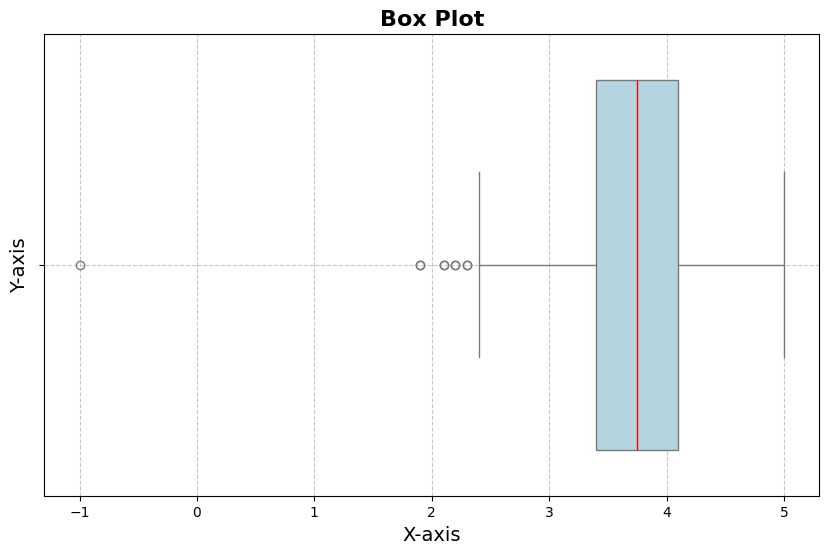

In [40]:
plot_boxplot(jobs, 'Rating')

In [41]:
# Just remove the -1 rating entry
jobs.drop(jobs[jobs['Rating']==-1].index, inplace = True)

### `salary` column

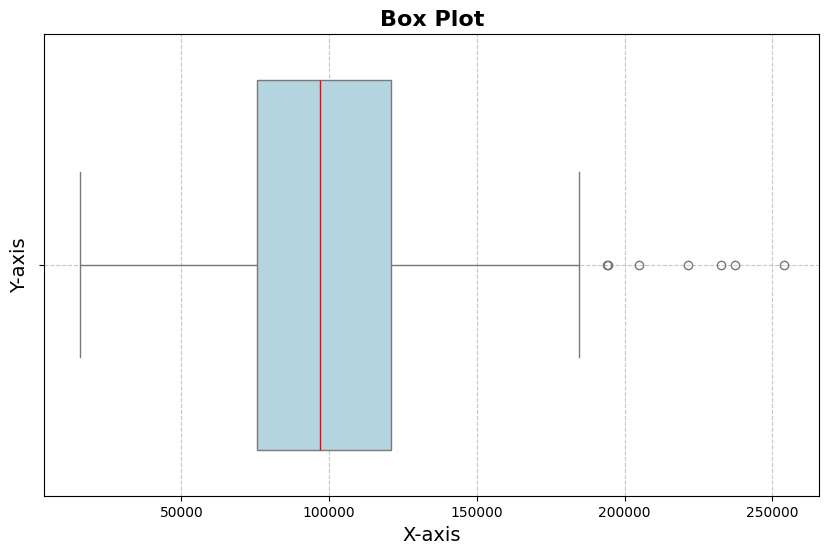

In [42]:
plot_boxplot(jobs, 'salary')

In [43]:
# Determine outliers based on iqr
outliers = get_outliers(jobs, 'salary')

jobs.drop(jobs[outliers].index, inplace = True)

## Multivariate Outlier detection

In [44]:
# Add mahalanobis distances for each row
jobs['mahala_dist'] = mahalanobis_distances(jobs)

In [45]:
# calculate threshold for mahala distance
threshold = calculate_threshold(jobs)

In [46]:
len(jobs[jobs['mahala_dist']>threshold])

0

In [47]:
jobs.drop(columns = ['mahala_dist'], axis = 1, inplace = True)

# Univariate Analysis

## `Rating` column

In [48]:
jobs['Rating'].describe()

,Rating
count,452.000000
mean,3.720796
std,0.569484
min,1.900000
25%,3.400000
50%,3.750000
75%,4.100000
max,5.000000


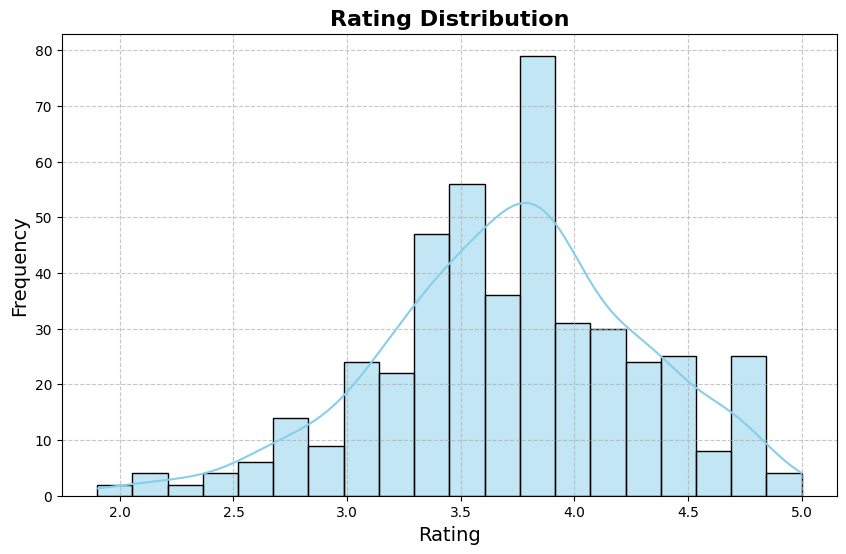

In [49]:
plot_histogram(data=jobs,
                          column='Rating',
                          title='Rating Distribution',
                          xlabel='Rating',
                          ylabel='Frequency',
                          bins=20)

**This histogram shows:**

- **Peak Distribution:** Most ratings for companies offering jobs center around 3.5 to 4.0.
- **Skewed Distribution:** Predominantly higher ratings, with a left skew.
- **Low Frequency:** Rare ratings below 2.5 and above 4.75, highlighting minimal extremes.

The data suggests general satisfaction with job-offering companies, with few extreme opinions.

## `Company Name` column

In [50]:
jobs['Company Name'].nunique()

332

In [51]:
jobs['Company Name'].value_counts()

,count
Company Name,
MassMutual,8
Takeda Pharmaceuticals,7
PNNL,6
Reynolds American,6
Software Engineering Institute,5
...,...
Johns Hopkins Health Care,1
Community Behavioral Health,1
FORMA THERAPEUTICS,1


In [52]:
# Step 1: Calculate the frequency of each company
company_counts = jobs['Company Name'].value_counts()

# Step 2: Identify the top 10 companies
top_10_companies = company_counts.nlargest(10).index

# Step 3: Subset the original DataFrame to include only rows with these top 10 companies
top_10_companies_jobs = jobs[jobs['Company Name'].isin(top_10_companies)]

/tmp/ipython-input-2009131738.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x_column, data=data, palette=palette)


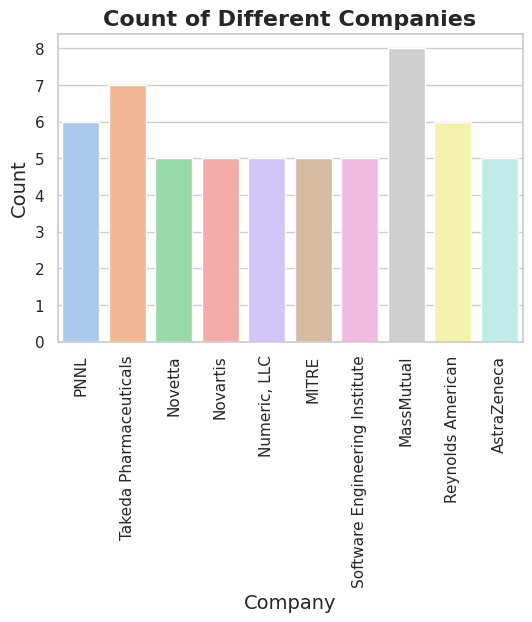

In [53]:
plot_bar_chart(data=top_10_companies_jobs,
                        x_column='Company Name',
                        title='Count of Different Companies',
                        xlabel='Company',
                        ylabel='Count',
                        x_label_rotation = 90)

**This bar chart shows:**

- **Peak Count:** MassMutual has the highest count among the companies, with 8 occurrences.
- **Consistent Frequency:** Several companies, including Takeda Pharmaceuticals, PNNL, and Software Engineering Institute, have counts around 6 to 7, indicating a relatively consistent frequency.
- **Lower Counts:** Companies like Reynolds American and AstraZeneca have lower counts, around 5, suggesting fewer occurrences in the dataset.

This distribution suggests that while MassMutual is the most frequently mentioned, other companies also show strong representation, indicating a diverse range of job opportunities across multiple companies.

## `Location` column

In [54]:
jobs['Location'].nunique()

200

In [55]:
jobs['Location'].value_counts()

,count
Location,
"New York, NY",36
"San Francisco, CA",29
"Cambridge, MA",24
"Chicago, IL",16
"Boston, MA",13
...,...
"Watertown, MA",1
"Cambridge, MD",1
"Irvine, CA",1


In [56]:
# Step 1: Calculate the frequency of each Location
location_counts = jobs['Location'].value_counts()

# Step 2: Identify the top 10 Locations
top_10_locations = location_counts.nlargest(10).index

# Step 3: Subset the original DataFrame to include only rows with these top 10 companies
top_10_location_jobs = jobs[jobs['Location'].isin(top_10_locations)]

/tmp/ipython-input-2009131738.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x_column, data=data, palette=palette)


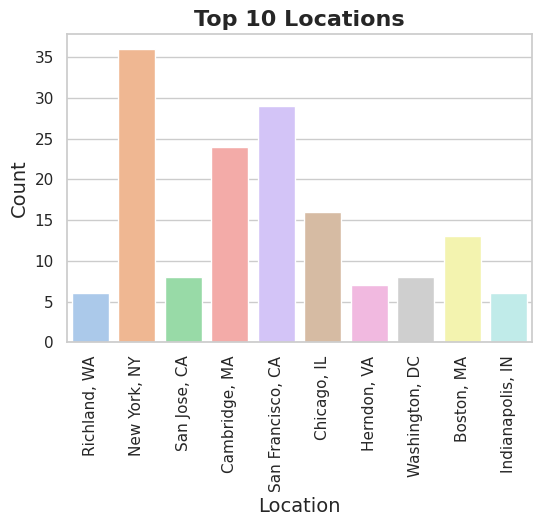

In [57]:
plot_bar_chart(data=top_10_location_jobs,
                        x_column='Location',
                        title='Top 10 Locations',
                        xlabel='Location',
                        ylabel='Count',
                        x_label_rotation = 90)

**This bar chart shows:**

- **Peak Count:** New York, NY, has the highest count, with over 35 occurrences, indicating it as the most frequent location for job opportunities.
- **High Representation:** San Francisco, CA, and Cambridge, MA, also have significant counts, with around 25 and 20 occurrences, respectively.
- **Lower Counts:** Locations like Indianapolis, IN, and Pittsburgh, PA, have lower counts, around 5 to 10, suggesting fewer job postings in these areas.

This distribution suggests that major cities like New York, San Francisco, and Cambridge are key hubs for job opportunities, while other locations have comparatively fewer job postings.

## `Size` column

In [58]:
jobs['Size'].nunique()

8

In [59]:
jobs['Size'].value_counts()

,count
Size,
1001 to 5000 employees,92
10000+ employees,78
501 to 1000 employees,77
201 to 500 employees,76
51 to 200 employees,59
5001 to 10000 employees,46
1 to 50 employees,23
Unknown,1


/tmp/ipython-input-2009131738.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x_column, data=data, palette=palette)


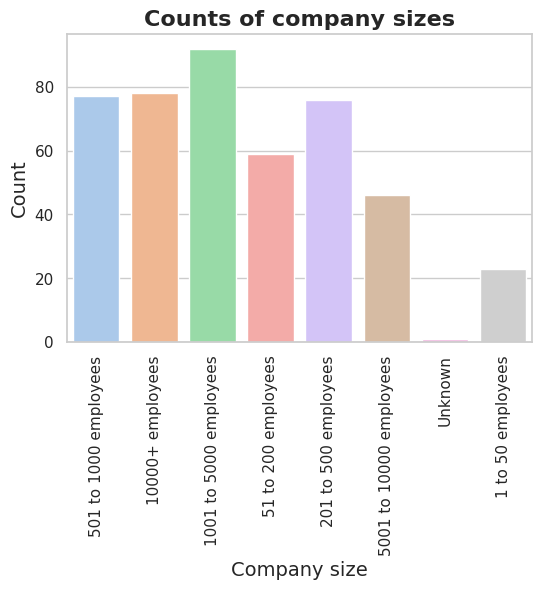

In [60]:
plot_bar_chart(data=jobs,
                        x_column='Size',
                        title='Counts of company sizes',
                        xlabel='Company size',
                        ylabel='Count',
                        x_label_rotation = 90)

**This bar chart shows:**

- **Peak Count:** Companies with 1001 to 5000 employees are the most common, with over 80 occurrences.
- **High Representation:** Companies with 10000+ employees and those with 501 to 1000 employees also have high counts, around 70 to 80.
- **Lower Counts:** Smaller companies with 1 to 50 employees and those with an unknown size have the lowest counts, suggesting fewer job postings from these companies.

This distribution suggests that mid-sized to large companies (especially those with 1001 to 5000 employees) dominate the job market in this dataset, while very small companies or those with unknown sizes are less represented.

In [61]:
jobs.drop(jobs[jobs['Size']=='Unknown'].index, inplace = True)

## `Type of ownership` column

In [62]:
jobs['Type of ownership'].nunique()

10

In [63]:
jobs['Type of ownership'].value_counts()

,count
Type of ownership,
Company - Private,250
Company - Public,120
Nonprofit Organization,32
Subsidiary or Business Segment,23
Government,9
Hospital,6
College / University,6
Other Organization,2
School / School District,2


/tmp/ipython-input-2009131738.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x_column, data=data, palette=palette)


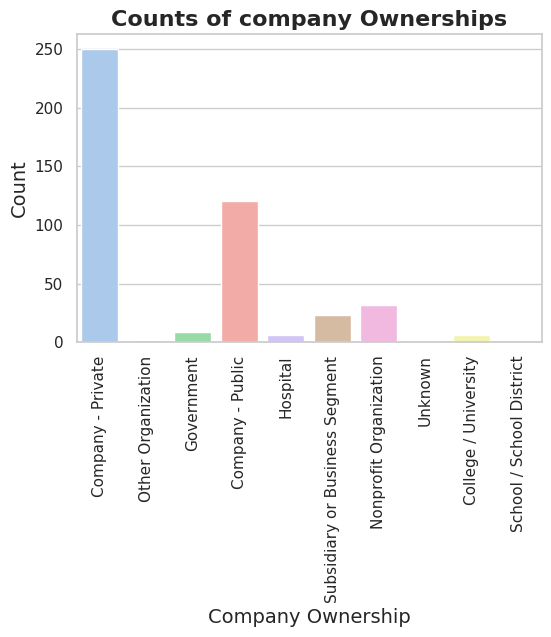

In [64]:
plot_bar_chart(data=jobs,
                        x_column='Type of ownership',
                        title='Counts of company Ownerships',
                        xlabel='Company Ownership',
                        ylabel='Count',
                        x_label_rotation = 90)

**This bar chart shows:**

- **Peak Count:** Private companies dominate the chart, with around 250 occurrences, far outpacing other ownership types.
- **High Representation:** Public companies also have a significant presence, with over 100 occurrences.
- **Lower Counts:** Other ownership types, such as nonprofits, government, and educational institutions, have relatively low counts, each with fewer than 20 occurrences.

This distribution suggests that the majority of job opportunities are concentrated in private companies, with public companies also playing a major role. Other types of ownerships contribute much less to the job market in this dataset.

In [65]:
jobs.drop(jobs[jobs['Type of ownership'] == 'Unknown'].index, inplace = True)

## `Sector` column

In [66]:
jobs['Sector'].nunique()

24

In [67]:
jobs['Sector'].value_counts()

,count
Sector,
Information Technology,119
Business Services,68
Biotech & Pharmaceuticals,62
Insurance,39
Finance,25
Health Care,24
Aerospace & Defense,20
Manufacturing,18
Education,14


/tmp/ipython-input-2009131738.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x_column, data=data, palette=palette)


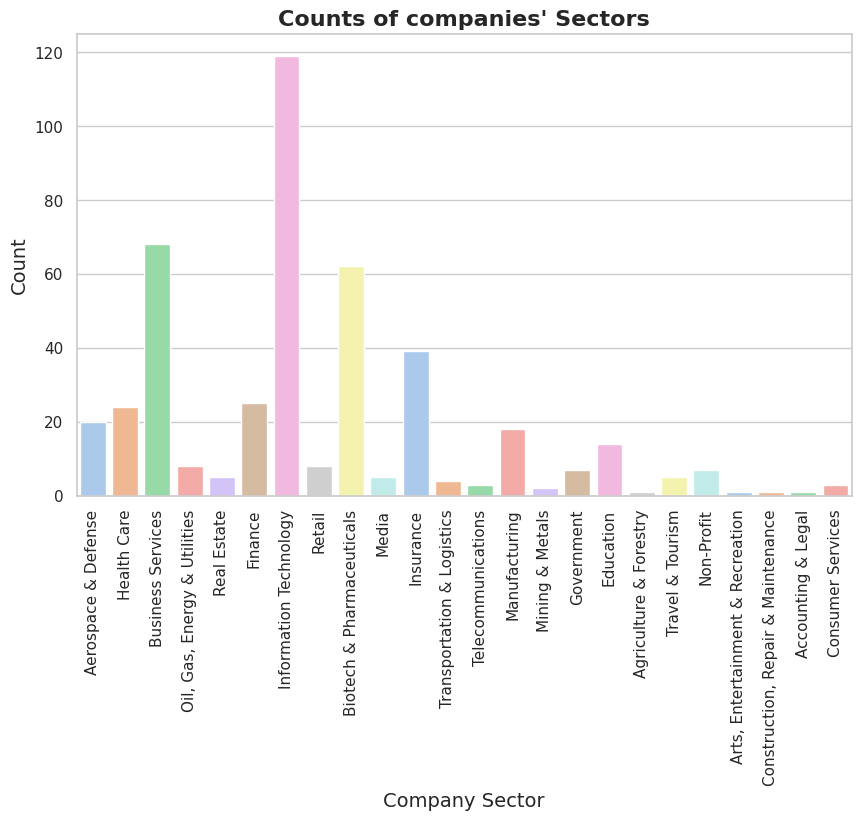

In [68]:
plot_bar_chart(data=jobs,
                        x_column='Sector',
                        title='Counts of companies\' Sectors',
                        xlabel='Company Sector',
                        ylabel='Count',
                        x_label_rotation = 90,
                        figsize = (10,6))

**This bar chart shows:**

- **Peak Count:** The Information Technology sector has the highest count, with around 120 occurrences, making it the dominant sector in this dataset.
- **High Representation:** The Business Services and Health Care sectors also have significant counts, with around 60 and 50 occurrences, respectively.
- **Lower Counts:** Several sectors, including Agriculture & Forestry, Aerospace & Defense, and Arts, Entertainment & Recreation, have minimal representation, each with fewer than 10 occurrences.

This distribution suggests that the job market in this dataset is heavily concentrated in Information Technology, followed by Business Services and Health Care, while other sectors contribute far less to the overall job opportunities.

## `Revenue` column

In [69]:
jobs['Revenue'].nunique()

13

In [70]:
jobs['Revenue'].value_counts()

,count
Revenue,
Unknown / Non-Applicable,123
$10+ billion (USD),68
$100 to $500 million (USD),57
$1 to $2 billion (USD),39
$500 million to $1 billion (USD),34
$50 to $100 million (USD),29
$2 to $5 billion (USD),26
$25 to $50 million (USD),21
$10 to $25 million (USD),21


/tmp/ipython-input-2009131738.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x_column, data=data, palette=palette)


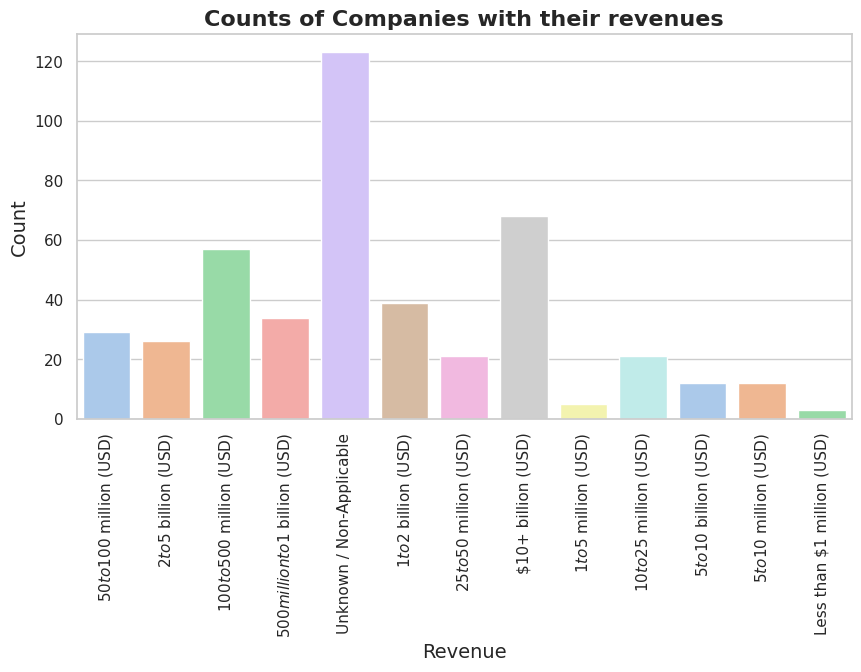

In [71]:
plot_bar_chart(data=jobs,
                        x_column='Revenue',
                        title='Counts of Companies with their revenues',
                        xlabel='Revenue',
                        ylabel='Count',
                        x_label_rotation = 90,
                        figsize = (10,5))

**This bar chart shows:**

- **Peak Count:** The "Unknown / Non-Applicable" category dominates, with over 120 occurrences, suggesting a large number of companies for which revenue data is not available or not applicable.
- **High Representation:** Companies with revenues in the "10+ billion dollars" and "100 to 500 million dollars" ranges are also well represented, with around 60 and 50 occurrences, respectively.
- **Lower Counts:** Companies with revenues less than "1 million dollars" and between "1 to 5 million dollars" have the fewest occurrences, indicating fewer small companies in the dataset.

This distribution suggests that while many companies do not have available or applicable revenue data, there is a significant presence of large companies with substantial revenues. Smaller companies, particularly those with very low revenues, are less represented.

## `salary` column

In [72]:
jobs['salary'].describe()

,salary
count,450.000000
mean,99294.533333
std,32994.836383
min,15500.000000
25%,75500.000000
50%,96500.000000
75%,120375.000000
max,184500.000000


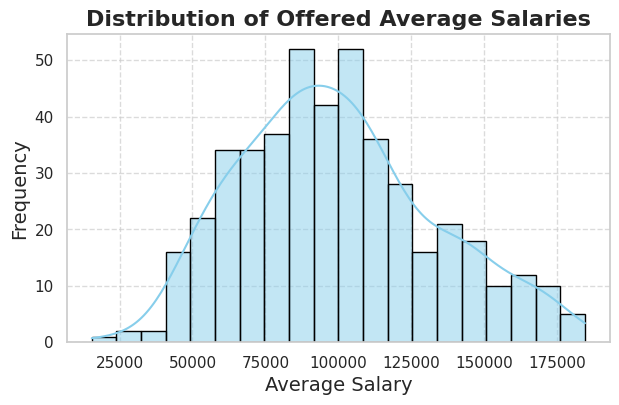

In [73]:
plot_histogram(data=jobs,
                          column='salary',
                          title='Distribution of Offered Average Salaries',
                          xlabel='Average Salary',
                          ylabel='Frequency',
                          bins=20,
                          figsize = (7,4))

**This histogram shows:**

- **Peak Distribution:** The majority of offered average salaries cluster between 75,000 and 100,000 dollars, with the highest frequency around this range.
- **Symmetric Distribution:** The distribution is relatively symmetric, suggesting that salaries are fairly evenly distributed around the central range.
- **Lower Frequencies:** As the average salary increases beyond 100,000 dollars, the frequency decreases steadily, with fewer offers above 150,000 dollars.

This distribution suggests that most job offers provide salaries in the mid-range, with fewer high-paying positions available.

## `Role` column

In [74]:
jobs['Role'].nunique()

7

In [75]:
jobs['Role'].value_counts()

,count
Role,
Data Scientist,203
Data Analyst,81
Data Engineer,73
Research Scientist,72
Other,10
Machine Learning Engineer,10
Software Developer,1


/tmp/ipython-input-2009131738.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x_column, data=data, palette=palette)


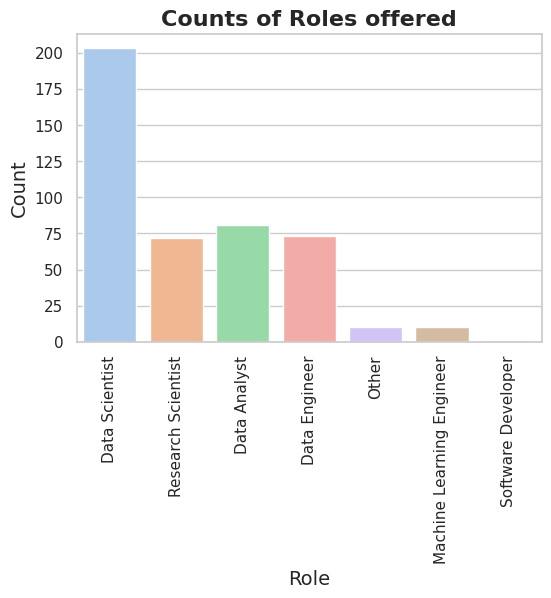

In [76]:
plot_bar_chart(data=jobs,
                        x_column='Role',
                        title='Counts of Roles offered',
                        xlabel='Role',
                        ylabel='Count',
                        x_label_rotation = 90
                       )

**This bar chart shows:**

- **Peak Count:** The role of Data Scientist is the most offered, with around 200 occurrences, far exceeding other roles.
- **Moderate Representation:** Roles such as Research Scientist, Data Analyst, and Data Engineer have moderate counts, each with around 50 to 75 occurrences.
- **Lower Counts:** Roles like Machine Learning Engineer and Software Developer have the fewest occurrences, indicating fewer job opportunities in these areas.

This distribution suggests a strong demand for Data Scientists, with significant but smaller demand for Research Scientists, Data Analysts, and Data Engineers. Roles in Machine Learning Engineering and Software Development are less frequently offered in comparison.

# Bivariate Analysis

## `Company Name` and `salary` Columns

In [77]:
jobs.groupby("Company Name")['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Company Name,,,,,,,,
"1-800-FLOWERS.COM, Inc.",1.0,76500.000000,NaN,76500.0,76500.0,76500.0,76500.0,76500.0
1904labs,1.0,143500.000000,NaN,143500.0,143500.0,143500.0,143500.0,143500.0
23andMe,1.0,92000.000000,NaN,92000.0,92000.0,92000.0,92000.0,92000.0
7Park Data,1.0,121000.000000,NaN,121000.0,121000.0,121000.0,121000.0,121000.0
<intent>,1.0,140000.000000,NaN,140000.0,140000.0,140000.0,140000.0,140000.0
...,...,...,...,...,...,...,...,...
e-IT Professionals Corp.,1.0,139500.000000,NaN,139500.0,139500.0,139500.0,139500.0,139500.0
goTRG,1.0,85500.000000,NaN,85500.0,85500.0,85500.0,85500.0,85500.0
h2o.ai,3.0,147166.666667,8504.900548,137500.0,144000.0,150500.0,152000.0,153500.0


In [78]:
# Step 1: Calculate the average salary for each company
average_salaries = jobs.groupby('Company Name')['salary'].mean()

# Step 2: Identify the top 15 companies with the highest average salaries
top_15_companies = average_salaries.nlargest(15).index

# Step 3: Subset the original DataFrame to include only rows with these top 15 companies
top_15_companies_jobs = jobs[jobs['Company Name'].isin(top_15_companies)]

# Now, top_15_companies_jobs will contain only the rows for the top 15 companies based on the highest average salary

/tmp/ipython-input-2009131738.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)


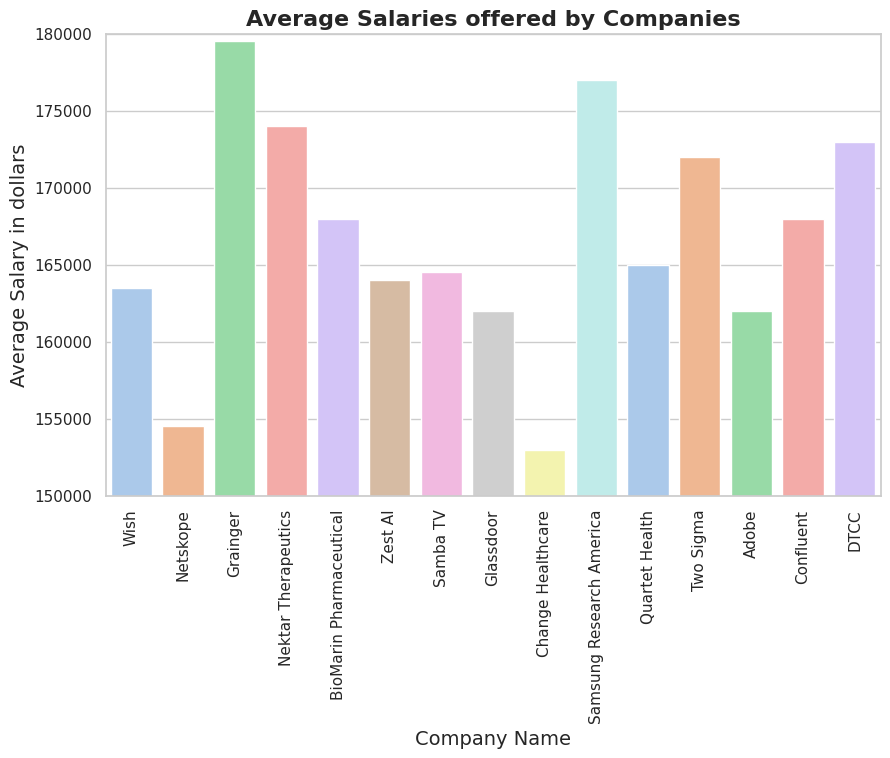

In [79]:
plot_bar_chart(
    data=top_15_companies_jobs,
    x_column='Company Name',
    y_column = 'salary',
    title='Average Salaries offered by Companies',
    xlabel='Company Name',
    ylabel='Average Salary in dollars',
    y_range = (150000, 180000),
    figsize = (10,6),
    x_label_rotation = 90
)

**This bar chart shows:**

- **Peak Average Salary:** Grainger offers the highest average salary, around 180,000 dollars, making it the top-paying company among the selected ones.
- **High Salaries:** Samsung Research America, Nektar Therapeutics, and DTCC also offer high average salaries, ranging between 170,000 and 175,000 dollars.
- **Moderate Salaries:** Companies like Wish, Zest AI, and BioMarin Pharmaceutical offer average salaries in the range of 160,000 to 165,000 dollars.
- **Lower Salaries:** BPA Services and Netskope are among the lower-paying companies in this group, with average salaries around 150,000 to 155,000 dollars.

This distribution suggests a significant variation in average salaries offered by different companies, with the top-paying companies providing salaries close to or above 170,000 dollars.

## `Location` and `salary` Columns

In [80]:
jobs.groupby("Location")['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Location,,,,,,,,
"Agoura Hills, CA",1.0,101000.000000,NaN,101000.0,101000.0,101000.0,101000.0,101000.0
"Alameda, CA",2.0,93750.000000,8838.834765,87500.0,90625.0,93750.0,96875.0,100000.0
"Albuquerque, NM",2.0,73750.000000,2474.873734,72000.0,72875.0,73750.0,74625.0,75500.0
"Alexandria, VA",1.0,71000.000000,NaN,71000.0,71000.0,71000.0,71000.0,71000.0
"Aliso Viejo, CA",1.0,113000.000000,NaN,113000.0,113000.0,113000.0,113000.0,113000.0
...,...,...,...,...,...,...,...,...
"Winston-Salem, NC",4.0,92875.000000,19661.192741,74000.0,78875.0,90000.0,104000.0,117500.0
"Winter Park, FL",1.0,71500.000000,NaN,71500.0,71500.0,71500.0,71500.0,71500.0
"Woburn, MA",1.0,110000.000000,NaN,110000.0,110000.0,110000.0,110000.0,110000.0


In [81]:
# Step 1: Calculate the average salary for each company
average_salaries = jobs.groupby('Location')['salary'].mean()

# Step 2: Identify the top 15 companies with the highest average salaries
top_15_locations = average_salaries.nlargest(15).index

# Step 3: Subset the original DataFrame to include only rows with these top 15 companies
top_15_locations_jobs = jobs[jobs['Location'].isin(top_15_locations)]

# Now, top_15_companies_jobs will contain only the rows for the top 15 companies based on the highest average salary

/tmp/ipython-input-2009131738.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)


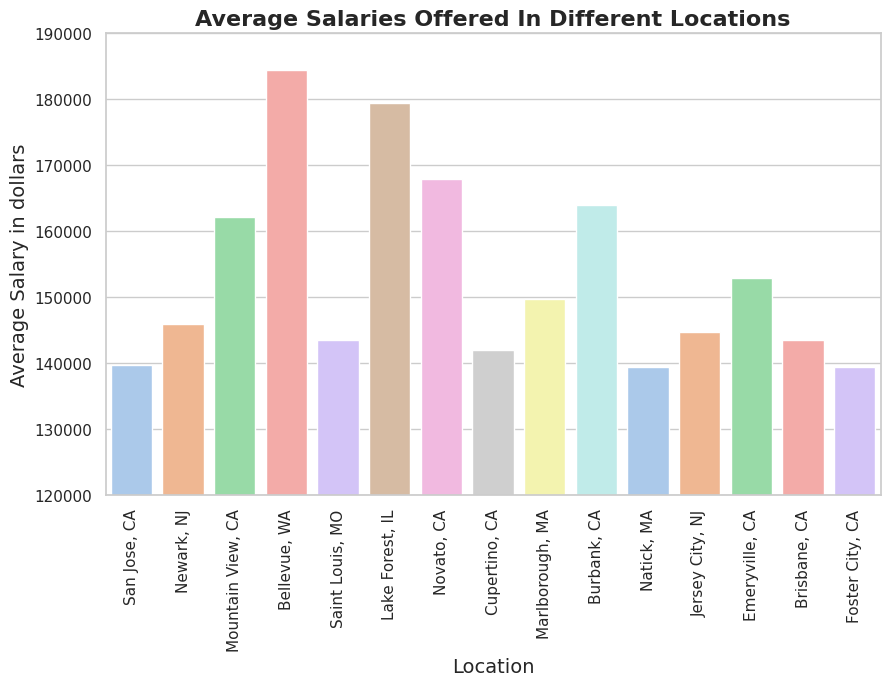

In [82]:
plot_bar_chart(
    data=top_15_locations_jobs,
    x_column='Location',
    y_column = 'salary',
    title='Average Salaries Offered In Different Locations',
    xlabel='Location',
    ylabel='Average Salary in dollars',
    y_range = (120000, 190000),
    figsize = (10,6),
    x_label_rotation = 90
)

**This bar chart shows:**

- **Peak Average Salary:** Bellevue, WA, offers the highest average salary, around 185,000 dollars, making it the top-paying location among the selected ones.
- **High Salaries:** Lake Forest, IL, and Marlborough, MA, also offer high average salaries, around 180,000 dollars and 170,000 dollars, respectively.
- **Moderate Salaries:** Locations like Mountain View, CA, and Burbank, CA, provide average salaries ranging from 160,000 to 170,000 dollars.
- **Lower Salaries:** San Jose, CA, and Jersey City, NJ, are among the lower-paying locations in this group, with average salaries around 150,000 to 155,000 dollars.

This distribution suggests that salaries vary significantly by location, with certain areas like Bellevue, WA, and Lake Forest, IL, offering notably higher pay compared to other locations.

## `Size` and `salary` Columns


In [83]:
jobs.groupby("Size")['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Size,,,,,,,,
1 to 50 employees,23.0,108744.347826,29384.249929,55120.0,91000.0,109000.0,128000.0,169000.0
10000+ employees,78.0,107565.384615,35637.692824,41600.0,84500.0,102000.0,134750.0,184500.0
1001 to 5000 employees,92.0,95523.043478,33604.697727,15500.0,69625.0,95000.0,115125.0,177000.0
201 to 500 employees,76.0,97914.473684,30790.191962,44000.0,77875.0,95250.0,111750.0,181000.0
5001 to 10000 employees,46.0,97156.956522,33148.350981,28080.0,76000.0,96750.0,116250.0,164000.0
501 to 1000 employees,77.0,90409.350649,31228.859727,40500.0,65520.0,87000.0,107000.0,168000.0
51 to 200 employees,58.0,105706.206897,31642.414175,48000.0,84625.0,105000.0,131875.0,180000.0


/tmp/ipython-input-2009131738.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)


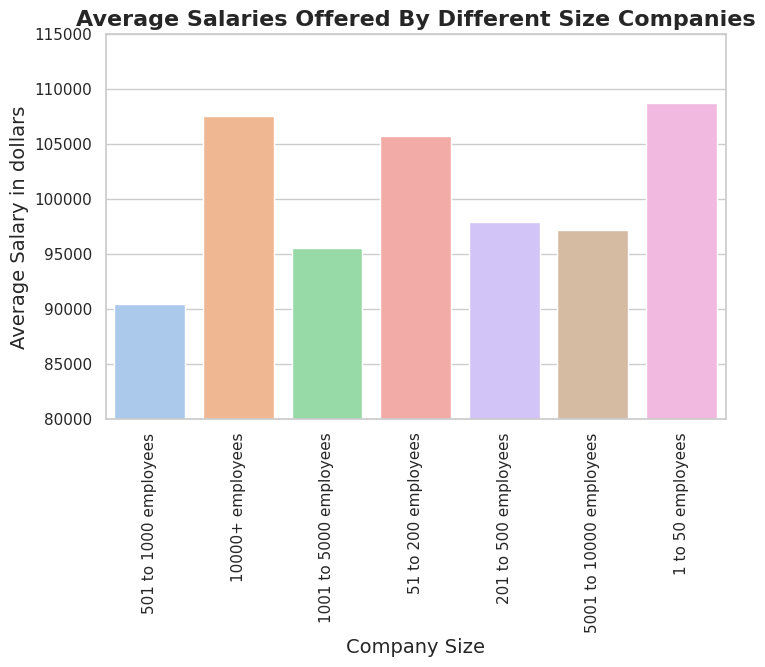

In [84]:
plot_bar_chart(
    data=jobs,
    x_column='Size',
    y_column = 'salary',
    title='Average Salaries Offered By Different Size Companies',
    xlabel='Company Size',
    ylabel='Average Salary in dollars',
    y_range = (80000, 115000),
    figsize = (8,5),
    x_label_rotation = 90
)

**This bar chart shows:**

- **Peak Average Salary:** Companies with 1 to 50 employees offer the highest average salary, around 110,000 dollars, indicating that smaller companies tend to offer higher pay.
- **High Salaries:** Companies with 10,000+ employees also offer high average salaries, close to 105,000 dollars.
- **Moderate Salaries:** Companies with 51 to 200 employees and 1,001 to 5,000 employees offer salaries around 100,000 dollars.
- **Lower Salaries:** Companies with 501 to 1,000 employees and 201 to 500 employees are among the lower-paying groups, with average salaries ranging from 85,000 to 90,000 dollars.

This distribution suggests that both very small and very large companies tend to offer higher average salaries, while mid-sized companies offer comparatively lower pay.

In [85]:
jobs.head(2)

,Rating,Company Name,Location,Size,Type of ownership,Sector,Revenue,salary,Role
0,3.8,Tecolote Research,"Albuquerque, NM",501 to 1000 employees,Company - Private,Aerospace & Defense,$50 to $100 million (USD),72000.0,Data Scientist
1,3.4,University of Maryland Medical System,"Linthicum, MD",10000+ employees,Other Organization,Health Care,$2 to $5 billion (USD),87500.0,Data Scientist


## `Type of ownership` and `salary` Columns


In [86]:
jobs.groupby("Type of ownership")['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Type of ownership,,,,,,,,
College / University,6.0,109083.333333,19213.059794,73500.0,106000.0,113750.0,123000.0,124000.0
Company - Private,250.0,98014.320000,32223.558616,15500.0,74125.0,95250.0,114875.0,181000.0
Company - Public,120.0,110121.500000,32487.472043,28080.0,87875.0,106000.0,137375.0,184500.0
Government,9.0,82955.555556,25548.831241,41600.0,67000.0,76500.0,98500.0,120000.0
Hospital,6.0,66956.666667,15344.885359,44720.0,61125.0,63510.0,79755.0,84500.0
Nonprofit Organization,32.0,75766.875000,23765.508001,42640.0,56025.0,71750.0,94500.0,130000.0
Other Organization,2.0,80000.000000,10606.601718,72500.0,76250.0,80000.0,83750.0,87500.0
School / School District,2.0,77750.000000,25809.397513,59500.0,68625.0,77750.0,86875.0,96000.0
Subsidiary or Business Segment,23.0,105282.608696,39420.756556,37500.0,74500.0,103000.0,126500.0,177000.0


/tmp/ipython-input-2009131738.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)


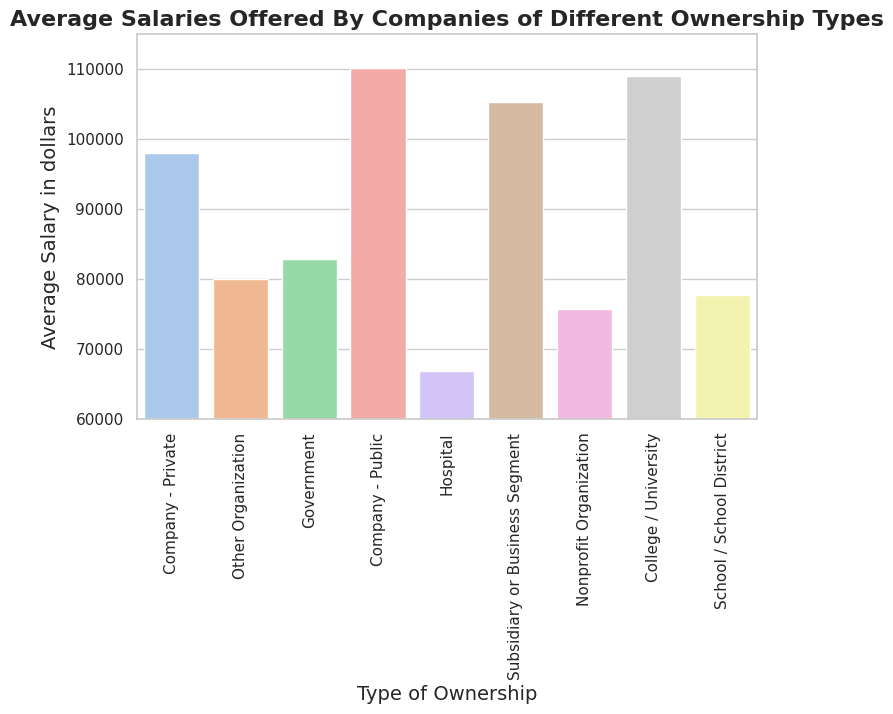

In [87]:
plot_bar_chart(
    data=jobs,
    x_column='Type of ownership',
    y_column = 'salary',
    title='Average Salaries Offered By Companies of Different Ownership Types',
    xlabel='Type of Ownership',
    ylabel='Average Salary in dollars',
    y_range = (60000, 115000),
    figsize = (8,5),
    x_label_rotation = 90
)

**This bar chart shows:**

- **Peak Average Salary:** Public companies offer the highest average salary, around 110,000 dollars, making them the top-paying ownership type.
- **High Salaries:** Subsidiaries or business segments and colleges/universities also offer high average salaries, close to 105,000 dollars.
- **Moderate Salaries:** Private companies and government organizations provide average salaries ranging from 90,000 to 100,000 dollars.
- **Lower Salaries:** Hospitals and school districts are among the lower-paying ownership types, with average salaries around 70,000 to 80,000 dollars.

This distribution suggests that public companies and subsidiaries/business segments tend to offer higher salaries, while organizations like hospitals and school districts typically offer lower pay.

## `Rating` and `salary` Columns


In [88]:
jobs['Rating'].corr(jobs['salary'])

np.float64(0.10308595635901624)

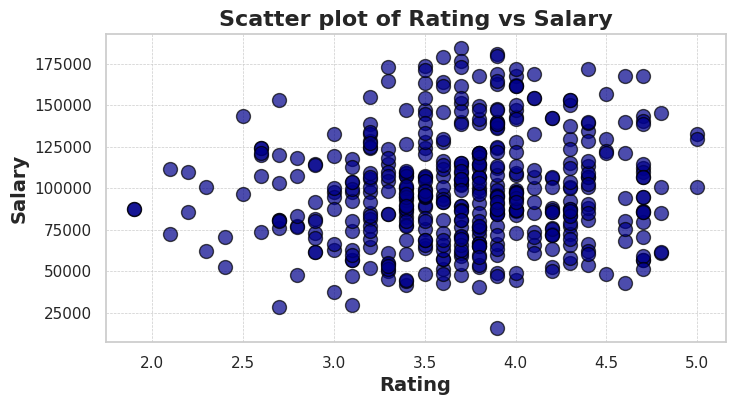

In [89]:
# Set the style of the plot
sns.set(style="whitegrid")

# Create the scatter plot with customizations
plt.figure(figsize=(8, 4))  # Adjust figure size
plt.scatter(jobs['Rating'], jobs['salary'], color='darkblue', edgecolor='black', s=100, alpha=0.7, marker='o')

# Customize labels and title
plt.xlabel('Rating', fontsize=14, fontweight='bold')
plt.ylabel('Salary', fontsize=14, fontweight='bold')
plt.title('Scatter plot of Rating vs Salary', fontsize=16, fontweight='bold')

# Customize the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Show the plot
plt.show()


**This scatter plot shows:**

- **Diverse Salary Distribution:** Salaries range widely across different ratings, with no strong linear relationship between salary and rating.
- **Concentration:** The majority of salaries cluster between 75,000 and 125,000 dollars, especially for ratings between 3.0 and 4.0.
- **Outliers:** Some salaries exceed 150,000 dollars, but these are distributed across a wide range of ratings, indicating that higher ratings do not consistently correlate with higher salaries.

This distribution suggests that salary is not strongly dependent on the company's rating, and other factors likely play a more significant role in determining salary levels.

## `Sector` and `salary` Columns


In [90]:
jobs.groupby("Sector")['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Sector,,,,,,,,
Accounting & Legal,1.0,113500.000000,NaN,113500.0,113500.0,113500.0,113500.0,113500.0
Aerospace & Defense,20.0,99275.000000,25462.291520,59000.0,86875.0,100750.0,109625.0,173000.0
Agriculture & Forestry,1.0,80500.000000,NaN,80500.0,80500.0,80500.0,80500.0,80500.0
"Arts, Entertainment & Recreation",1.0,48500.000000,NaN,48500.0,48500.0,48500.0,48500.0,48500.0
Biotech & Pharmaceuticals,62.0,114007.419355,31866.835679,62000.0,86750.0,112000.0,140000.0,174000.0
Business Services,68.0,94198.529412,31952.756603,15500.0,71500.0,91750.0,114125.0,179500.0
"Construction, Repair & Maintenance",1.0,55120.000000,NaN,55120.0,55120.0,55120.0,55120.0,55120.0
Consumer Services,3.0,100666.666667,37350.814360,65000.0,81250.0,97500.0,118500.0,139500.0
Education,14.0,102535.714286,29702.022908,59500.0,78500.0,106500.0,120750.0,169000.0


/tmp/ipython-input-2009131738.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)


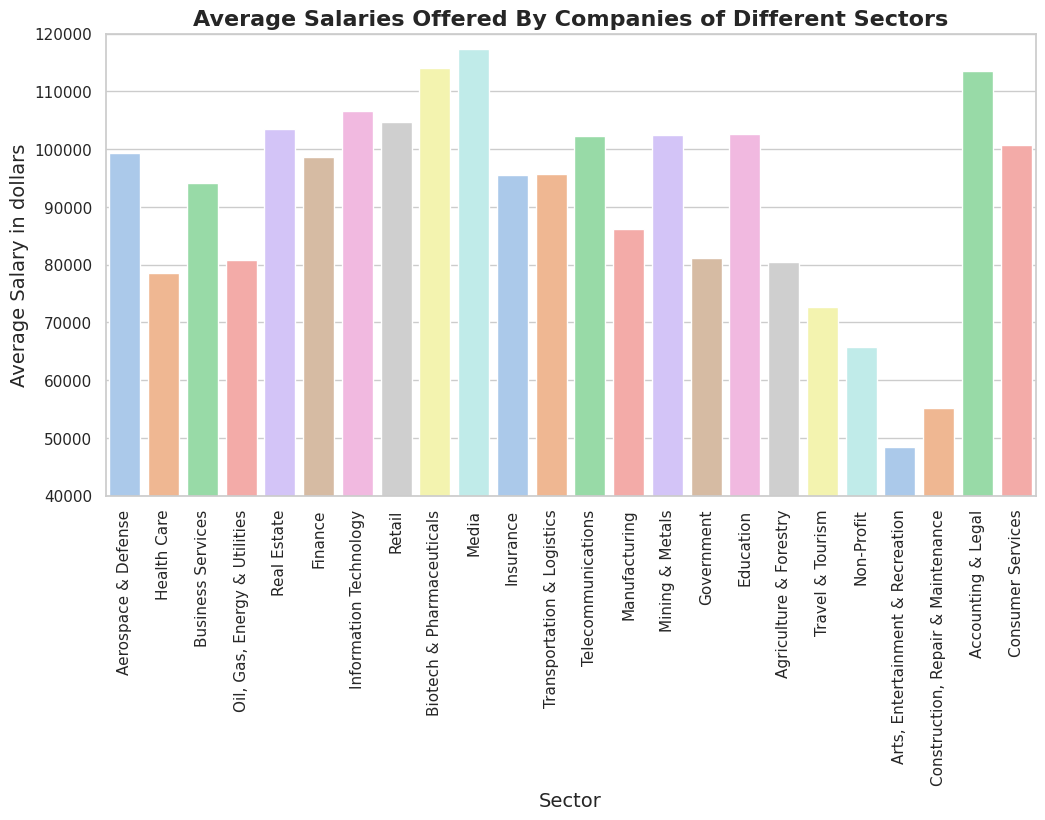

In [91]:
plot_bar_chart(
    data=jobs,
    x_column='Sector',
    y_column = 'salary',
    title='Average Salaries Offered By Companies of Different Sectors',
    xlabel='Sector',
    ylabel='Average Salary in dollars',
    y_range = (40000, 120000),
    figsize = (12,6),
    x_label_rotation = 90
)



**This bar chart shows:**

- **Peak Average Salary:** The Accounting & Legal sector offers the highest average salary, exceeding 115,000 dollars.
- **High Salaries:** Sectors like Construction, Repair & Maintenance, Real Estate, and Consumer Services also offer high average salaries, generally ranging between 105,000 and 115,000 dollars.
- **Moderate Salaries:** Many sectors, such as Aerospace & Defense, Finance, and Information Technology, offer moderate salaries ranging from 95,000 to 105,000 dollars.
- **Lower Salaries:** Sectors like Non-Profit, Education, and Arts, Entertainment & Recreation are among the lower-paying industries, with average salaries below 80,000 dollars.

This distribution suggests that certain sectors, particularly Accounting & Legal, and Construction, Repair & Maintenance, tend to offer higher salaries, while sectors like Non-Profit and Education generally offer lower salaries.

## `Revenue` and `salary` Columns


In [92]:
jobs.groupby("Revenue")['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
$1 to $2 billion (USD),39.0,104128.205128,30626.939885,60000.0,80500.0,97500.0,131750.0,173000.0
$1 to $5 million (USD),5.0,115800.000000,18209.200971,94500.0,102000.0,118000.0,124000.0,140500.0
$10 to $25 million (USD),21.0,95902.857143,33504.345560,47000.0,76960.0,96500.0,108000.0,181000.0
$10+ billion (USD),68.0,111139.705882,34907.964877,51500.0,86250.0,103500.0,139000.0,184500.0
$100 to $500 million (USD),57.0,91068.771930,33139.542849,15500.0,65520.0,88000.0,107500.0,174000.0
$2 to $5 billion (USD),26.0,92291.538462,34518.868196,28080.0,67000.0,90000.0,111000.0,162500.0
$25 to $50 million (USD),21.0,79500.000000,23124.121605,44500.0,60500.0,80500.0,95000.0,122500.0
$5 to $10 billion (USD),12.0,92000.000000,36828.225342,47500.0,60250.0,93500.0,107500.0,162000.0
$5 to $10 million (USD),12.0,114750.000000,29393.490312,74000.0,93000.0,108500.0,131250.0,167500.0


/tmp/ipython-input-2009131738.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)


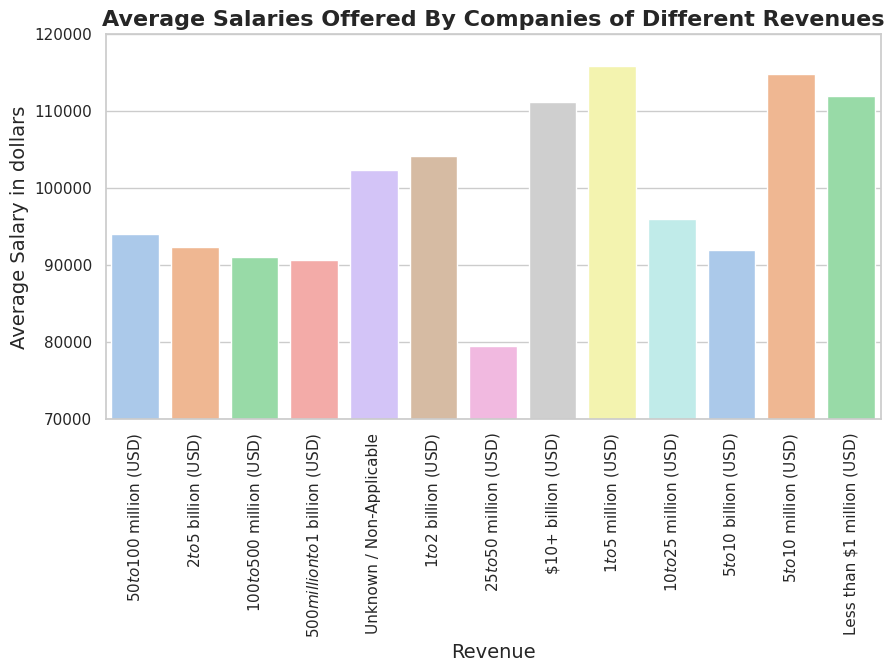

In [93]:
plot_bar_chart(
    data=jobs,
    x_column='Revenue',
    y_column = 'salary',
    title='Average Salaries Offered By Companies of Different Revenues',
    xlabel='Revenue',
    ylabel='Average Salary in dollars',
    y_range = (70000, 120000),
    figsize = (10,5),
    x_label_rotation = 90
)


**This bar chart shows:**

- **Peak Average Salary:** Companies with revenues of **1 to 5 million dollars** offer the highest average salary, close to 115,000 dollars.
- **High Salaries:** Companies with revenues of **1 to 2 billion dollars** and **25 to 50 million dollars** also offer high average salaries, slightly above 110,000 dollars.
- **Moderate Salaries:** Companies with revenues of **50 to 100 million dollars** and **10+ billion dollars** offer average salaries around 105,000 dollars.
- **Lower Salaries:** Companies with revenues of **500 million to 1 billion dollars** offer the lowest average salaries, around 85,000 dollars.

This distribution indicates that companies with revenues of **1 to 5 million dollars** tend to offer the highest salaries, while those in the **500 million to 1 billion dollars** range offer the lowest average salaries.

## `Role` and `salary` Columns


In [94]:
jobs.groupby("Role")['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Role,,,,,,,,
Data Analyst,81.0,68877.530864,24531.543853,28080.0,53500.0,63000.0,77500.0,173000.0
Data Engineer,73.0,101527.397260,25127.852300,58500.0,87000.0,98000.0,110500.0,177000.0
Data Scientist,203.0,113078.817734,29756.955998,15500.0,89250.0,110000.0,137250.0,184500.0
Machine Learning Engineer,10.0,117600.000000,27221.111088,87000.0,102250.0,115500.0,124750.0,181000.0
Other,10.0,85750.000000,25258.936812,48000.0,71375.0,89000.0,100375.0,129500.0
Research Scientist,72.0,91805.000000,33732.968911,41600.0,68880.0,84500.0,103500.0,174000.0
Software Developer,1.0,93500.000000,NaN,93500.0,93500.0,93500.0,93500.0,93500.0


/tmp/ipython-input-2009131738.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_column, y=y_column, data=data, palette=palette, errorbar=None)


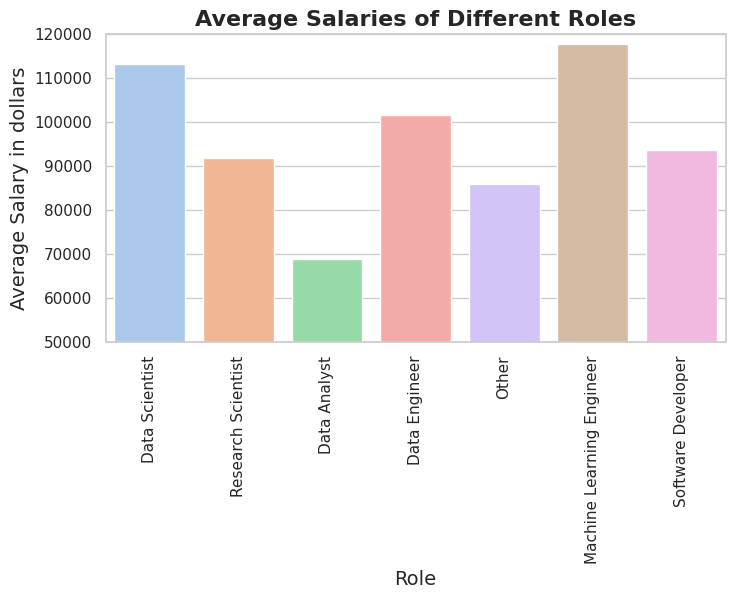

In [95]:
plot_bar_chart(
    data=jobs,
    x_column='Role',
    y_column = 'salary',
    title='Average Salaries of Different Roles',
    xlabel='Role',
    ylabel='Average Salary in dollars',
    y_range = (50000, 120000),
    figsize = (8,4),
    x_label_rotation = 90
)

**This bar chart shows:**

- **Peak Average Salary:** The role of Machine Learning Engineer offers the highest average salary, around 120,000 dollars.
- **High Salaries:** Data Scientists also command high average salaries, slightly above 110,000 dollars.
- **Moderate Salaries:** Roles such as Data Engineer and Software Developer offer moderate salaries, ranging from 90,000 to 100,000 dollars.
- **Lower Salaries:** Data Analysts receive the lowest average salary, around 70,000 dollars, while the 'Other' category is also on the lower end, with average salaries close to 80,000 dollars.

This distribution suggests that specialized roles like Machine Learning Engineer and Data Scientist are compensated at a higher rate, while more general roles such as Data Analyst tend to offer lower salaries.